## Script to read in, modify and plot aerosol emissions data for a CAM run
### - Read in data
### - Select region on globe modify the values of the data
### - Write to separate file.

In [2]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import cartopy.crs as ccrs
from cartopy.feature import LAND


In [3]:
## Biomass burning files.

#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_bc_a4_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_DMS_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_pom_a4_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_SO2_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_so4_a1_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_SOAGx1.5_bb_surface_2000climo_0.9x1.25_c20170322'
var_name = 'emiss_bb'  ; emis_file =  'emissions-cmip6_SO2_bb_surface_1750-2015_0.9x1.25_c20170322'


#var_name = 'emiss_anthro' ; emis_file =  'emissions-cmip6_bc_a4_anthro_surface_2000climo_0.9x1.25_c20170608'

emis_dir0 = '/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/'

#emis_type = 'CMIP6_emissions_2000climo'
emis_type = 'CMIP6_emissions_1750_2015'

emis_dir = emis_dir0+emis_type+'/'


ds_in = xr.open_dataset(emis_dir+emis_file+'.nc')
ds_in.emiss_bb

<xarray.DataArray 'emiss_bb' (time: 3192, lat: 192, lon: 288)> Size: 706MB
[176504832 values with dtype=float32]
Coordinates:
  * lon      (lon) float32 1kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lat      (lat) float32 768B -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * time     (time) datetime64[ns] 26kB 1750-01-16 1750-02-16 ... 2015-12-16
Attributes:
    units:             molecules/cm2/s
    long_name:         CEDS SO2*0.975 biomass burning emissions
    molecular_weight:  64.0

In [6]:
#da_in = ds_in.emiss_bb
#print(da_in)


reg = 'global'
#reg = 'amazon' ;  mmin_lon = 290. ;   mmax_lon = 305. ;   mmin_lat = -20.   ; mmax_lat = -5. ; pmin_lon = 270 ;   pmax_lon = 320. ;   pmin_lat = -30.  ; pmax_lat = 15.
#reg = 'na-boreal' ;  mmin_lon = 190. ;   mmax_lon = 310. ;   mmin_lat = 50.   ; mmax_lat = 70. ; pmin_lon = 181. ;   pmax_lon = 320. ;   pmin_lat = 40.  ; pmax_lat = 80.
#reg = 'na-boreal' ;  mmin_lon = 190. ;   mmax_lon = 310. ;   mmin_lat = 50.   ; mmax_lat = 70. ; pmin_lon = 181. ;   pmax_lon = 320. ;   pmin_lat = 40.  ; pmax_lat = 80.

imonth = 4

# Sub-domain plot

#mask_lon = (da_in.lon >= pmin_lon) & (da_in.lon <= pmax_lon)
#mask_lat = (da_in.lat >= pmin_lat) & (da_in.lat <= pmax_lat)

#da_in = da_in.where(mask_lon & mask_lat, drop=True)



# Sub-domain plot mask

#mask_lon = (da_in.lon >= mmin_lon) & (da_in.lon <= mmax_lon)
#mask_lat = (da_in.lat >= mmin_lat) & (da_in.lat <= mmax_lat)

#da_mod = da_in.copy()
#print(da_mod[:,:])
#print(da_in)
#da_mod = da_mod.where(mask_lon & mask_lat, 1000) #

vscale = 2
#da_mod.loc[{"lat": mask_lat, "lon": mask_lon}] = 10e16
#da_mod.loc[{"lat": mask_lat, "lon": mask_lon}] = vscale*da_mod.loc[{"lat": mask_lat, "lon": mask_lon}]


#da_mod = vscale*da_mod
ds_in['emiss_bb'].data = vscale*ds_in['emiss_bb'].data

#ds_in[var_name] = da_mod
ds_in.emiss_bb

<xarray.DataArray 'emiss_bb' (time: 3192, lat: 192, lon: 288)> Size: 706MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 1kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lat      (lat) float32 768B -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * time     (time) datetime64[ns] 26kB 1750-01-16 1750-02-16 ... 2015-12-16
Attributes:
    units:             molecules/cm2/s
    long_name:         CEDS SO2*0.975 biomass burning emissions
    molecular_weight:  64.0

<xarray.Dataset> Size: 706MB
Dimensions:   (lon: 288, lat: 192, time: 3192)
Coordinates:
  * lon       (lon) float32 1kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lat       (lat) float32 768B -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * time      (time) datetime64[ns] 26kB 1750-01-16 1750-02-16 ... 2015-12-16
Data variables:
    date      (time) int32 13kB ...
    emiss_bb  (time, lat, lon) float32 706MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    data_title:        Biomass burning emissions of SO2 for CMIP6
    molecular_weight:  64.0
    data_creator:      Jean-Francois Lamarque (lamar@ucar.edu) and Louisa Emm...
    data_summary:      Emissions from the Community Emission Data System (CED...
    cesm_contact:      Louisa Emmons or Simone Tilmes
    creation_date:     20170322
    update_date:       20170323
    history:           original files have been regridded, units changed, con...
    data_script:       /glade/u/home/emmons/CMIP6/emissions/make_emis_cmip

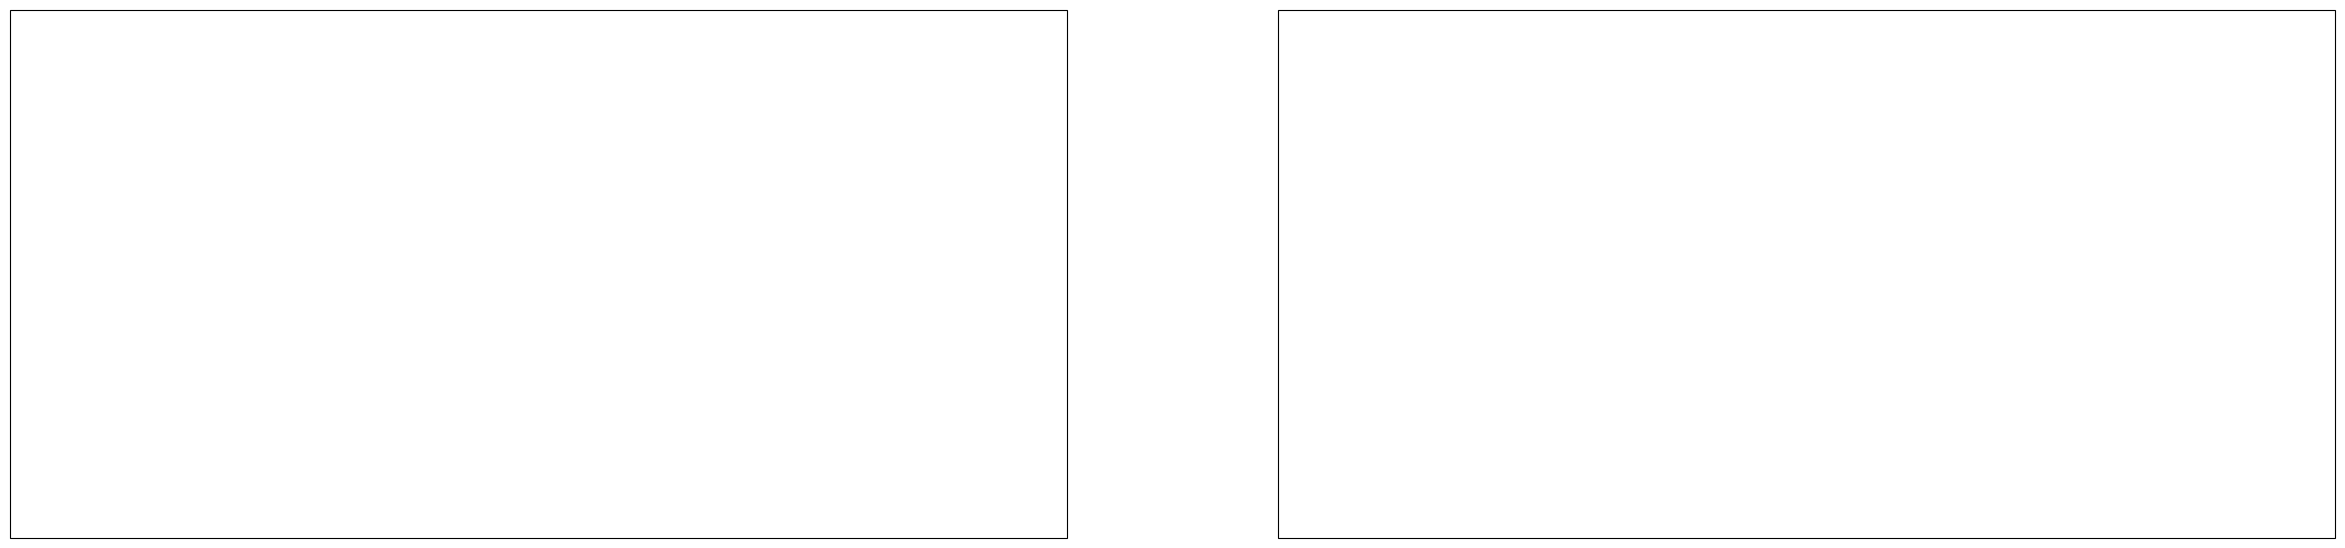

In [8]:
fig, axs = plt.subplots(nrows=1,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(30,30))

cmap = 'ocean_r'


#cs1 = axs[0].contourf(da_in.lon,da_in.lat,da_in[imonth,:,:],levels=100,cmap=cmap)
#cs1 = axs[1].contourf(da_in.lon,da_in.lat,da_mod[imonth,:,:],levels=100,cmap=cmap)

#axs.set_global()
#ax.set_extent([80, 170, -20, 20])

# Calculate box dims
#bxy = [mmin_lon,mmin_lat]
#bx = (mmax_lon-mmin_lon)
#by = (mmax_lat-mmin_lat)

#print(bx,by,bxy)

#axs[0].add_patch(mpatches.Rectangle(xy=bxy, width=bx, height=by,
#                                    facecolor='k',
#                                    alpha=0.2,
#                                    transform=ccrs.PlateCarree())
#                 )

#axs[1].add_patch(mpatches.Rectangle(xy=bxy, width=bx, height=by,
#                                    facecolor='k',
#                                    alpha=0.2,
#                                    transform=ccrs.PlateCarree())
#                 )

#axs[0].gridlines()
#axs[1].gridlines()
#axs[0].add_feature(LAND,color='k')
#axs[1].add_feature(LAND,color='k')

#axs[0].set_title('Default')
#axs[1].set_title('Modified')
#axs[0].coastlines()
#axs[1].coastlines()

#fig.colorbar(cs1)

#print(reg+'_'+emis_file+'.png')

#plt.savefig(reg+'_'+emis_file+'.png', dpi=120, bbox_inches='tight') 
#plt.show()

print(ds_in)
## OUTPUT NETCDF ##
print(emis_file+'_'+reg+'_2x.nc')
ds_in.to_netcdf(path=emis_file+'_'+reg+'_2x.nc')

In [ ]:
bad_air2d[dict(lat=slice(0, 10), lon=slice(0, 25))] = np.nan

NameError: name 'bad_air2d' is not defined